## Plots for results

In [1]:
import numpy as np#
import matplotlib.pyplot as plt
import pickle
from scipy.stats import wilcoxon, mannwhitneyu, norm
plt.rcParams.update({
    "text.usetex": True,          
    "font.family": "serif",     
    "font.serif": ["Computer Modern"]
})

from __future__ import print_function

### plots

##### Comparison between methods

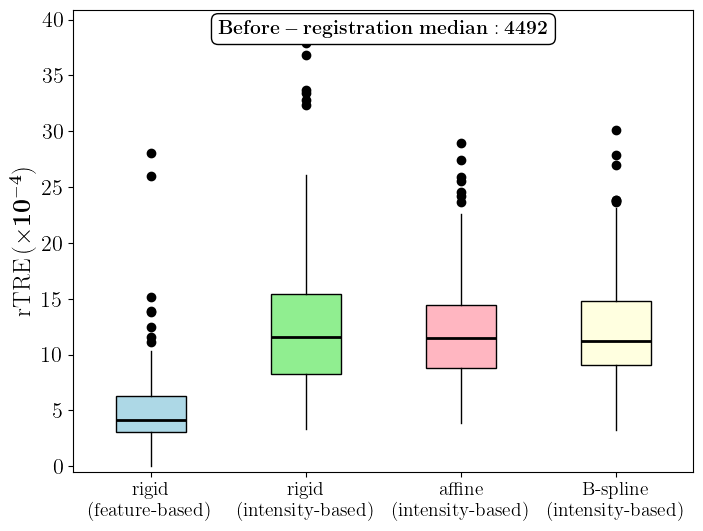

In [2]:
# Boxplot for different registration methods
# rTRE

tre_dict = np.load("result_plots_metrics_full_dataset/tre.npy", allow_pickle=True).item()

tre_metrics = [np.array(tre_dict["initial similarity"]), np.array(tre_dict["rigid"]), np.array(tre_dict["affine"]), np.array(tre_dict["bspline"])]

before_median = np.median(tre_dict["before registration"])

methods = ["rigid\n(feature-based)", "rigid\n(intensity-based)", "affine\n(intensity-based)", "B-spline\n(intensity-based)"]

# scaling to 10^-4 
tre_metrics = [arr * 1e4 for arr in tre_metrics]
before_median = before_median * 1e4


fig, ax = plt.subplots(figsize=(8,6))

box = ax.boxplot(tre_metrics, tick_labels=methods, patch_artist=True, showfliers=True, 
                 capprops=dict(color='none'), 
                 whiskerprops=dict(color='black'), 
                 boxprops=dict(color='black'), 
                 medianprops=dict(color='black', linewidth=2),
                 flierprops=dict(marker='o', markersize=6, markerfacecolor='black'))

colors = ["lightblue", "lightgreen", "lightpink", "lightyellow"]
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)

y_min = min(np.min(arr) for arr in tre_metrics)
y_max = max(np.max(arr) for arr in tre_metrics)

ax.set_ylim(y_min-0.5, y_max+3)

# add before registration median as text box
ax.text(
    2.5,
    y_max + 0.5,
    f"$\\mathbf{{Before-registration\ median: {before_median:.0f}}}$",
    ha="center",
    va="bottom",
    fontsize=14,
    bbox=dict(boxstyle="round,pad=0.35", fc="white", ec="black")
)

ax.set_ylabel(r"$\mathbf{\mathrm{rTRE} \, (\times 10^{-4})}$", fontsize=18)
#ax.set_title("Comparison of Registration Methods", fontsize=20)
ax.set_xticklabels(methods, fontweight='bold', fontsize=14)
ax.yaxis.set_tick_params(labelsize=16)
plt.show()


In [3]:
# wilcoxon signed-rank test for rTRE

ftr_tre_medians = []
r_tre_medians = []

with open("result_plots_metrics_full_dataset/tre_sep.npy", "rb") as f:
    tre_sep = np.load(f, allow_pickle=True).item()

ftr_tre_medians = np.array(tre_sep["initial similarity"])
r_tre_medians = np.array(tre_sep["rigid"])

mask = ~np.isnan(ftr_tre_medians) & ~np.isnan(r_tre_medians)
ftr_tre = ftr_tre_medians[mask]
r_tre = r_tre_medians[mask]

# paired differences
diff = ftr_tre - r_tre

# remove zero differences
diff_nonzero = diff[diff != 0]
N = len(diff_nonzero)

# Wilcoxon test
stat, p_value = wilcoxon(ftr_tre, r_tre, alternative='two-sided')

# compute mean and std of W under H0
mean_W = N * (N + 1) / 4
std_W = np.sqrt(N * (N + 1) * (2*N + 1) / 24)

# compute Z
z = (stat - mean_W) / std_W

# effect size
r = z / np.sqrt(N)

print("--------------------Wilcoxon signed-rank test--------------------")
print("Wilcoxon statistic:", stat)
print("p-value:", p_value)
print("Z:", z, "feature-based rigid better" if z < 0 else "intensity-based rigid better")
print("Effect size r:", r)

if p_value < 0.05:
    print("The median difference between feature-based and rigid intensity-based is not zero across image pairs, one method is consistently better.")
else:
    print("The median difference between feature-based and rigid intensity-based is zero across image pairs, neither method is consistently better.")

--------------------Wilcoxon signed-rank test--------------------
Wilcoxon statistic: 0.0
p-value: 1.4551915228366852e-11
Z: -5.302829433425141 feature-based rigid better
Effect size r: -0.8717797887081348
The median difference between feature-based and rigid intensity-based is not zero across image pairs, one method is consistently better.


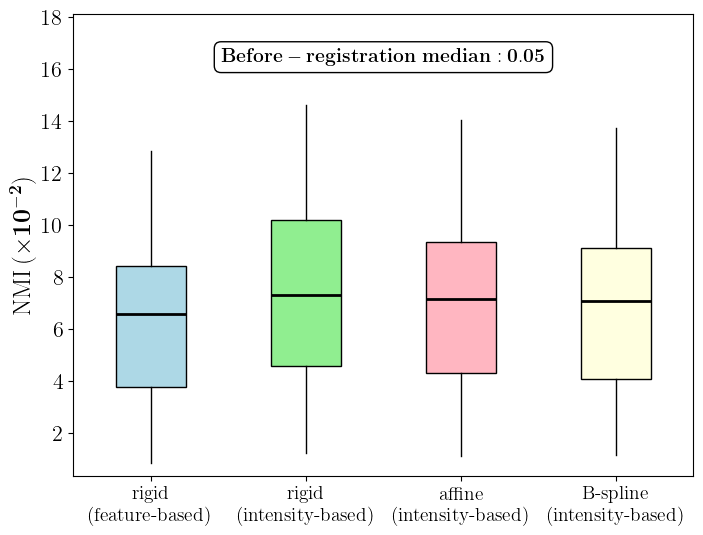

In [4]:
# Boxplot for different registration methods
# MI

mi_dict = np.load("result_plots_metrics_full_dataset/mi.npy", allow_pickle=True).item()

mi_metrics = [np.array(mi_dict["initial similarity"]), np.array(mi_dict["rigid"]), np.array(mi_dict["affine"]), np.array(mi_dict["bspline"])]

before_median = np.median(mi_dict["before registration"])

methods = ["rigid\n(feature-based)", "rigid\n(intensity-based)", "affine\n(intensity-based)", "B-spline\n(intensity-based)"]

# scaling to 10^-2 
mi_metrics = [arr * 1e2 for arr in mi_metrics]
before_median = before_median * 1e2


fig, ax = plt.subplots(figsize=(8,6))

box = ax.boxplot(mi_metrics, tick_labels=methods, patch_artist=True, showfliers=True,
                 capprops=dict(color='none'),
                 whiskerprops=dict(color='black'),
                 boxprops=dict(color='black'),
                 medianprops=dict(color='black', linewidth=2),
                 flierprops=dict(marker='o', markersize=6, markerfacecolor='black'))

# color the boxes
colors = ["lightblue", "lightgreen", "lightpink", "lightyellow"]
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)

y_min = min(np.min(arr) for arr in mi_metrics)
y_max = max(np.max(arr) for arr in mi_metrics)
ax.set_ylim(y_min - 0.5, y_max + 3.5)

# add before registration median as text box
ax.text(
    2.5,                   # middle of the x-axis
    y_max + 1.5,          # above the boxplots
    f"$\\mathbf{{Before-registration\ median: {before_median:.2f}}}$",
    ha="center",
    va="bottom",
    fontsize=14,
    bbox=dict(boxstyle="round,pad=0.35", fc="white", ec="black")
)

ax.set_ylabel(r"$\mathbf{\mathrm{NMI} \, (\times 10^{-2})}$", fontsize=18)
#ax.set_title("Comparison of Registration Methods", fontsize=20)
ax.set_xticklabels(methods, fontweight='bold', fontsize=14)
ax.yaxis.set_tick_params(labelsize=16)

plt.show()


In [5]:
# wilcoxon signed-rank test for MI

ftr_mi_medians = []
r_mi_medians = []

with open("result_plots_metrics_full_dataset/mi_sep.npy", "rb") as f:
    mi_sep = np.load(f, allow_pickle=True).item()

ftr_mi_medians = np.array(mi_sep["initial similarity"])
r_mi_medians = np.array(mi_sep["rigid"])

mask = ~np.isnan(ftr_mi_medians) & ~np.isnan(r_mi_medians)
ftr_mi = ftr_mi_medians[mask]
r_mi = r_mi_medians[mask]

# paired differences
diff = ftr_mi - r_mi

# remove zero differences
diff_nonzero = diff[diff != 0]
N = len(diff_nonzero)

# Wilcoxon test
stat, p_value = wilcoxon(ftr_mi, r_mi, alternative='two-sided')

# compute mean and std of W under H0
mean_W = N * (N + 1) / 4
std_W = np.sqrt(N * (N + 1) * (2*N + 1) / 24)

# compute Z
z = (stat - mean_W) / std_W

# effect size
r = z / np.sqrt(N)

print("--------------------Wilcoxon signed-rank test--------------------")
print("Wilcoxon statistic:", stat)
print("p-value:", p_value)
print("Z:", z, "feature-based rigid better" if z > 0 else "intensity-based rigid better")
print("Effect size r:", r)

if p_value < 0.05:
    print("The median difference between feature-based and rigid intensity-based is not zero across image pairs, one method is consistently better.")
else:
    print("The median difference between feature-based and rigid intensity-based is zero across image pairs, neither method is consistently better.")



--------------------Wilcoxon signed-rank test--------------------
Wilcoxon statistic: 0.0
p-value: 1.4551915228366852e-11
Z: -5.302829433425141 intensity-based rigid better
Effect size r: -0.8717797887081348
The median difference between feature-based and rigid intensity-based is not zero across image pairs, one method is consistently better.


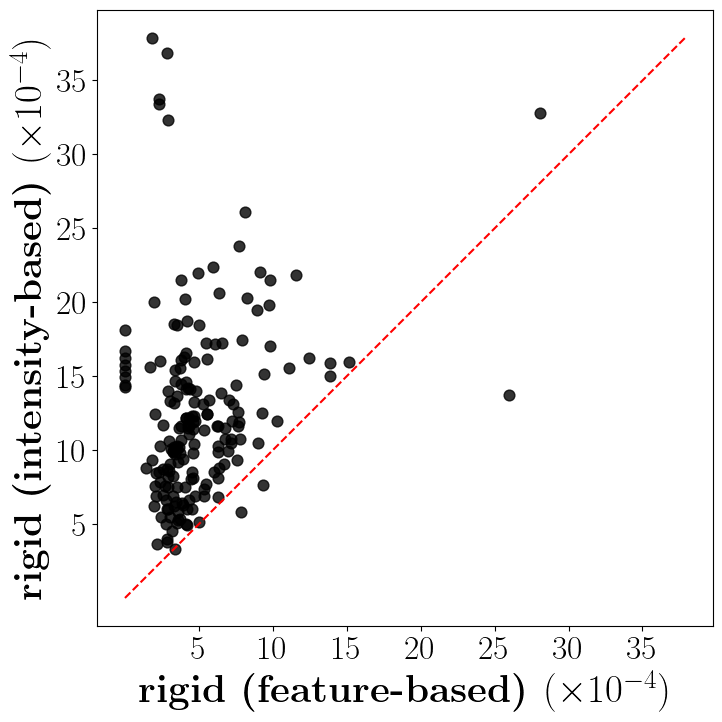

In [5]:
# Scatter plot comparing two methods 
# tre

ftr_r = tre_metrics[0] # rigid (feature-based)
intns = tre_metrics[1] # rigid (intensity-based)

fig, ax = plt.subplots(figsize=(8,8))

ax.scatter(ftr_r, intns, c='black', s=60, alpha=0.8, edgecolor='k')
min_val = min(ftr_r.min(), intns.min())
max_val = max(ftr_r.max(), intns.max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5)

ax.set_xticks([5, 10, 15, 20, 25, 30, 35])
ax.set_yticks([5, 10, 15, 20, 25, 30, 35])
#ax.set_yticks([10, 20, 30])

ax.set_xlabel(r"\textbf{rigid (feature-based) $(\times 10^{-4})$}", fontsize=28)
ax.set_ylabel(r"\textbf{rigid (intensity-based) $(\times 10^{-4})$}", fontsize=28)
#ax.set_title(r"\textbf{Pairwise Comparison of Two Methods with rTRE}", fontsize=20)
ax.yaxis.set_tick_params(labelsize=24)
ax.xaxis.set_tick_params(labelsize=24)
ax.set_aspect('equal', adjustable='box')  


plt.show()

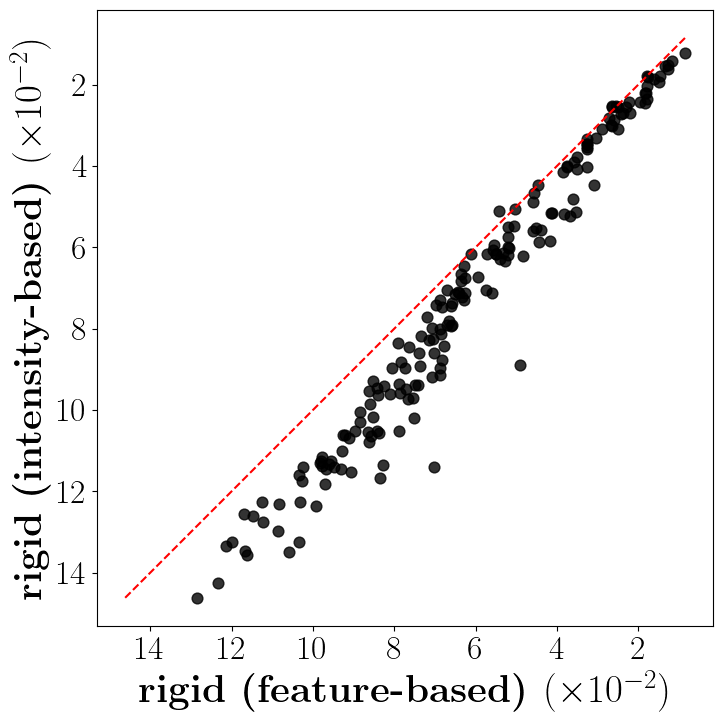

In [6]:
# Scatter plot comparing two methods 
# mi

ftr_r = mi_metrics[0] # rigid (feature-based)
intns = mi_metrics[1] # rigid (intensity-based)

fig, ax = plt.subplots(figsize=(8,8))

ax.scatter(ftr_r, intns, c='black', s=60, alpha=0.8, edgecolor='k')
min_val = min(ftr_r.min(), intns.min())
max_val = max(ftr_r.max(), intns.max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5)

ax.set_xticks([2, 4, 6, 8, 10, 12, 14])
ax.set_yticks([2, 4, 6, 8, 10, 12, 14])

ax.invert_yaxis()
ax.invert_xaxis()
ax.set_xlabel(r"\textbf{rigid (feature-based) $(\times 10^{-2})$}", fontsize=28)
ax.set_ylabel(r"\textbf{rigid (intensity-based) $(\times 10^{-2})$}", fontsize=28)
#ax.set_title(r"\textbf{Pairwise Comparison of Two Methods with NMI}", fontsize=20)
ax.yaxis.set_tick_params(labelsize=24)
ax.xaxis.set_tick_params(labelsize=24)
ax.set_aspect('equal', adjustable='box')  


plt.show()

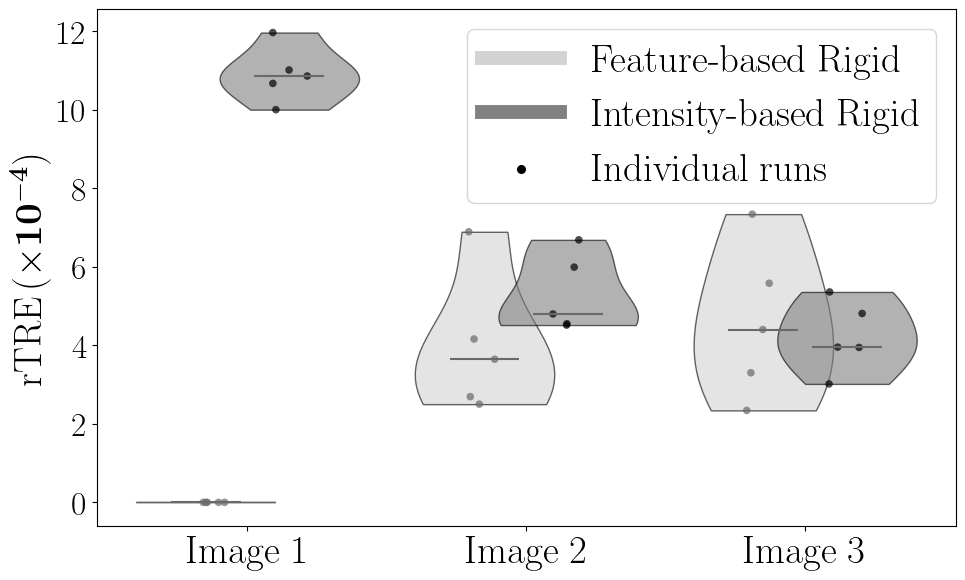

In [13]:
num_imgs = 3

# Colors
color_ftr = "lightgrey"
color_r   = "grey"  
scatter_ftr = "dimgray"
scatter_r = "black"

ftr_values = []
r_values = []

# Load data
for img_idx in range(num_imgs):
    # ftr
    with open(f"result_plots_metrics/{img_idx}_tre_ftr_dict.pkl", "rb") as f:
        tre_dict = pickle.load(f)
    vals_ftr = np.asarray(tre_dict[f"img_{img_idx+1}"]).ravel()
    ftr_values.append(vals_ftr)

    # r
    with open(f"result_plots_metrics/{img_idx}_tre_r_dict.pkl", "rb") as f:
        tre_dict = pickle.load(f)
    vals_r = np.asarray(tre_dict[f"img_{img_idx+1}"]).ravel()
    r_values.append(vals_r)

r_values = [value * 1e4 for value in r_values]
ftr_values = [value * 1e4 for value in ftr_values]

fig, ax = plt.subplots(figsize=(10, 6))
positions = np.arange(num_imgs)

# plot violins and scatter points
for i in range(num_imgs):
    for vals, pos, color, scatter_color in zip([ftr_values[i], r_values[i]],
                                               [positions[i]-0.15, positions[i]+0.15],
                                               [color_ftr, color_r],
                                               [scatter_ftr, scatter_r]):
        vp = ax.violinplot(
            vals,
            positions=[pos],
            widths=0.5,
            showmeans=False,
            showmedians=True,
            showextrema=False
        )
        for part in vp['bodies']:
            part.set_facecolor(color)
            part.set_edgecolor('black')
            part.set_alpha(0.6)
        vp['cmedians'].set_color('dimgray')

        # points for all runs
        jitter = np.random.uniform(-0.07, 0.07, size=len(vals))
        ax.scatter(pos + jitter, vals, color=scatter_color, s=30, alpha=0.7, edgecolors='none')


ax.set_xticks(positions)
ax.set_xticklabels([f"Image {i+1}" for i in range(num_imgs)], fontsize=28, fontweight='bold')
ax.set_ylabel(r"$\mathbf{\mathrm{rTRE} \, (\times 10^{-4})}$", fontsize=28, fontweight='bold')
#ax.set_title("Comparison of rTRE Distributions at Different Runs", fontsize=20)

# legend
ax.plot([], [], color=color_ftr, label="Feature-based Rigid", linewidth=10)
ax.plot([], [], color=color_r, label="Intensity-based Rigid", linewidth=10)
ax.scatter([], [], color=scatter_color, s=30, label="Individual runs")
ax.legend(fontsize=28)
ax.tick_params(axis='y', labelsize=24)  
for tick in ax.get_yticklabels():
    tick.set_fontweight('bold')

plt.tight_layout()
plt.show()


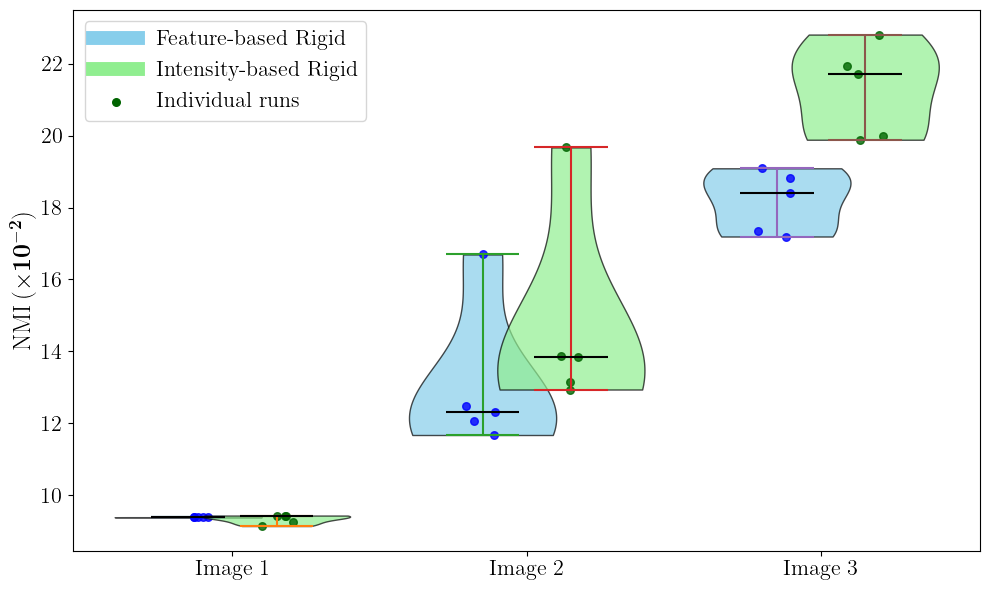

In [37]:
#violin plots for three images
num_imgs = 3

color_ftr = "skyblue"
color_r   = "lightgreen"  
scatter_ftr = "blue"
scatter_r = "darkgreen"

ftr_values = []
r_values = []

# load NMI data
for img_idx in range(num_imgs):
    # ftr
    with open(f"result_plots_metrics/{img_idx}_mi_ftr_dict.pkl", "rb") as f:
        nmi_dict = pickle.load(f)
    vals_ftr = np.asarray(nmi_dict[f"img_{img_idx+1}"]).ravel()
    ftr_values.append(vals_ftr)

    # r
    with open(f"result_plots_metrics/{img_idx}_mi_r_dict.pkl", "rb") as f:
        nmi_dict = pickle.load(f)
    vals_r = np.asarray(nmi_dict[f"img_{img_idx+1}"]).ravel()
    r_values.append(vals_r)


r_values = [value * 1e2 for value in r_values]
ftr_values = [value * 1e2 for value in ftr_values]

fig, ax = plt.subplots(figsize=(10, 6))
positions = np.arange(num_imgs)

# plot violins + scatter points
for i in range(num_imgs):
    for vals, pos, color, scatter_color in zip([ftr_values[i], r_values[i]],
                                               [positions[i]-0.15, positions[i]+0.15],
                                               [color_ftr, color_r],
                                               [scatter_ftr, scatter_r]):
        vp = ax.violinplot(
            vals,
            positions=[pos],
            widths=0.5,
            showmeans=False,
            showmedians=True
        )
        for part in vp['bodies']:
            part.set_facecolor(color)
            part.set_edgecolor('black')
            part.set_alpha(0.7)
        vp['cmedians'].set_color('black')

        # scatter points for all runs
        jitter = np.random.uniform(-0.07, 0.07, size=len(vals))
        ax.scatter(pos + jitter, vals, color=scatter_color, s=30, alpha=0.8)

ax.set_xticks(positions)
ax.set_xticklabels([f"Image {i+1}" for i in range(num_imgs)], fontsize=16, fontweight='bold')
ax.set_ylabel(r"$\mathbf{\mathrm{NMI} \, (\times 10^{-2})}$", fontsize=18, fontweight='bold')
#ax.set_title("Comparison of NMI Distributions at Different Runs", fontsize=20)

# legend
ax.plot([], [], color=color_ftr, label="Feature-based Rigid", linewidth=10)
ax.plot([], [], color=color_r, label="Intensity-based Rigid", linewidth=10)
ax.scatter([], [], color=scatter_color, s=30, label="Individual runs")
ax.legend(fontsize=16)
ax.tick_params(axis='y', labelsize=16)  
for tick in ax.get_yticklabels():
    tick.set_fontweight('bold')

plt.tight_layout()
plt.show()
